<a href="https://colab.research.google.com/github/antas06/DL_Scratch/blob/Root_functions/Cat_dog_classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

In [3]:
import tensorflow
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten

In [4]:
import kagglehub
path = kagglehub.dataset_download("tongpython/cat-and-dog")

Using Colab cache for faster access to the 'cat-and-dog' dataset.


In [5]:
path

'/kaggle/input/cat-and-dog'

In [6]:
import os
os.listdir(path)

['test_set', 'training_set']

In [7]:
train_set = os.path.join(path, 'training_set')
test_set = os.path.join(path, 'test_set')
print(os.listdir(train_set))
print(os.listdir(test_set))

['training_set']
['test_set']


In [8]:
train_set = os.path.join(train_set, 'training_set')
test_set = os.path.join(test_set, 'test_set')
print(os.listdir(train_set))
print(os.listdir(test_set))

['dogs', 'cats']
['dogs', 'cats']


In [30]:
#image_generators
train_ds = keras.utils.image_dataset_from_directory(
    train_set,
    batch_size=32,
    image_size=(256, 256),
    label_mode="int",
    labels = "inferred",
    validation_split=0.2,
    subset="training",
    seed=42
)

Found 8005 files belonging to 2 classes.
Using 6404 files for training.


In [31]:
test_ds = keras.utils.image_dataset_from_directory(
    train_set,
    batch_size=32,
    image_size=(256, 256),
    label_mode="int",
    labels = "inferred",
    validation_split=0.2,
    subset="validation",
    seed=42
)

Found 8005 files belonging to 2 classes.
Using 1601 files for validation.


In [32]:
type(train_ds)

tensorflow.python.data.ops.prefetch_op._PrefetchDataset

In [33]:
#NOrmalisation
def normal(image, label):
    image = tensorflow.cast(image/255.0, tensorflow.float32)
    return image, label

train_ds = train_ds.map(normal)
test_ds = test_ds.map(normal)

In [35]:
model = Sequential([
    Conv2D(32, (3, 3), activation='relu', input_shape=(256, 256, 3)),
    BatchNormalization(),
    MaxPooling2D((2, 2)),

    Conv2D(64, (3, 3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D((2, 2)),

    Conv2D(128, (3, 3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D((2, 2)),

    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.3),
    Dense(1, activation='sigmoid')
])

In [36]:
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

In [37]:
model.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_12 (Conv2D)              │ (None, 254, 254, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_9           │ (None, 254, 254, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_12 (MaxPooling2D) │ (None, 127, 127, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 125, 125, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_10          │ (None, 125, 125, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_13 (MaxPooling2D) │ (None, 62, 62, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_14 (Conv2D)              │ (None, 60, 60, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_11          │ (None, 60, 60, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_14 (MaxPooling2D) │ (None, 30, 30, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_4 (Flatten)             │ (None, 115200)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 128)            │    14,745,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,840,001 (56.61 MB)

 Trainable params: 14,839,553 (56.61 MB)

 Non-trainable params: 448 (1.75 KB)

In [39]:
history = model.fit(train_ds, epochs=20, validation_data=test_ds, verbose=1)

Epoch 1/20
201/201 ━━━━━━━━━━━━━━━━━━━━ 18s 88ms/step - accuracy: 0.8751 - loss: 0.2559 - val_accuracy: 0.7270 - val_loss: 1.0248
Epoch 2/20
201/201 ━━━━━━━━━━━━━━━━━━━━ 18s 89ms/step - accuracy: 0.8608 - loss: 0.2887 - val_accuracy: 0.7283 - val_loss: 0.9713
Epoch 3/20
201/201 ━━━━━━━━━━━━━━━━━━━━ 18s 89ms/step - accuracy: 0.8887 - loss: 0.2611 - val_accuracy: 0.7302 - val_loss: 0.7463
Epoch 4/20
201/201 ━━━━━━━━━━━━━━━━━━━━ 18s 91ms/step - accuracy: 0.8930 - loss: 0.2350 - val_accuracy: 0.7308 - val_loss: 1.2618
Epoch 5/20
201/201 ━━━━━━━━━━━━━━━━━━━━ 18s 88ms/step - accuracy: 0.9063 - loss: 0.2191 - val_accuracy: 0.6583 - val_loss: 1.4248
Epoch 6/20
201/201 ━━━━━━━━━━━━━━━━━━━━ 18s 92ms/step - accuracy: 0.9111 - loss: 0.1912 - val_accuracy: 0.7414 - val_loss: 0.9087
Epoch 7/20
201/201 ━━━━━━━━━━━━━━━━━━━━ 20s 88ms/step - accuracy: 0.9230 - loss: 0.1609 - val_accuracy: 0.7664 - val_loss: 1.1559
Epoch 8/20
201/201 ━━━━━━━━━━━━━━━━━━━━ 18s 89ms/step - accuracy: 0.9370 - loss: 0.1386 - 

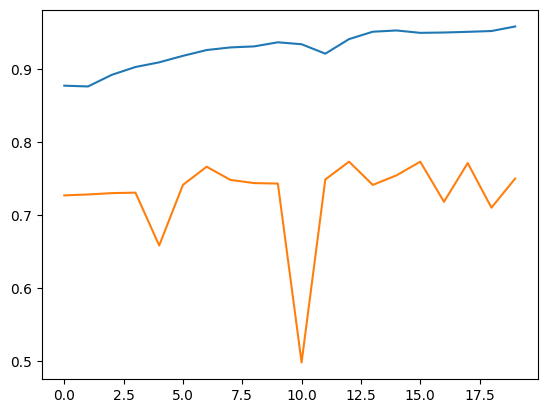

In [40]:
plt.plot(history.history['accuracy'], label='accuracy')
plt.plot(history.history['val_accuracy'], label='val_accuracy')